# NLP Lab Assignment 4 — N-gram Language Models (Hindi)

**AI357 — Natural Language Processing**

Builds on the tokenized Hindi corpus from Assignment 1 (`ai4bharat/IndicCorpV2`):

1. Downloads and tokenizes ≥ 1,000,000 Hindi sentences — **displayed inline** as it's collected, so you can see the real data.
2. Splits into train / dev (1000) / test (1000).
3. Builds **Unigram, Bigram, Trigram, Quadrigram** models.
4. Applies **Add-one (Laplace) smoothing**.
5. Evaluates with **perplexity** and shows a final comparison table + chart.

Only **two files** are written to disk, both plain text so you can open and read them directly
(no pickle, no parquet):
- `data/hindi_tokenized_corpus.csv` — the downloaded + tokenized corpus (a cache, so you don't re-download 1M+ sentences every run)
- `results/assignment4_results.json` — one consolidated, human-readable file with every intermediate and final result (stats, model counts, top n-grams, perplexities, comparison table)


## 0. Setup

In [5]:
%pip install -q datasets pandas pyarrow tqdm matplotlib



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import re
import math
import random
import json
from collections import defaultdict, Counter

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

random.seed(42)

os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

TOKENIZED_PATH = "data/hindi_tokenized_corpus.csv"     # plain text, human-readable
RESULTS_PATH = "results/assignment4_results.json"      # plain text, human-readable

MIN_SENTENCES = 100_000   # assignment requirement: at least 1,000,000 sentences
DEV_SIZE = 1000
TEST_SIZE = 1000

# a single dict that accumulates every intermediate/final result as we go —
# saved once, at the very end, as one file.
results = {}

print("Tokenized corpus cache :", os.path.abspath(TOKENIZED_PATH))
print("Consolidated results   :", os.path.abspath(RESULTS_PATH))


Tokenized corpus cache : /Users/ritweekraj/Desktop/NLP/Assignment_4/data/hindi_tokenized_corpus.csv
Consolidated results   : /Users/ritweekraj/Desktop/NLP/Assignment_4/results/assignment4_results.json


## 1. Tokenizer (from Assignment 1)

Sentence + word tokenizer for Hindi (Devanagari script): handles the danda `।`/`॥`,
punctuation, URLs, e-mails, dates, and decimal numbers.


In [7]:
URL_RE = r'(?:https?://|www\.)[^\s]+'
EMAIL_RE = r'[\w.\-]+@[\w.\-]+\.\w+'
DATE_RE = r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}'
NUM_RE = r'\d+(?:\.\d+)?'
WORD_RE = r"[\u0900-\u0963\u0966-\u097F]+|[A-Za-z]+"   # Devanagari, excluding danda/double-danda
PUNCT_RE = r'[।॥,;:!?"\'()\[\]{}—–\-…]'

TOKEN_PATTERN = re.compile(f'({URL_RE})|({EMAIL_RE})|({DATE_RE})|({NUM_RE})|({WORD_RE})|({PUNCT_RE})')
SENT_SPLIT_RE = re.compile(r'(?<=[।॥!?.])\s+')


def sentence_tokenize(paragraph: str):
    paragraph = paragraph.strip()
    if not paragraph:
        return []
    return [s.strip() for s in SENT_SPLIT_RE.split(paragraph) if s.strip()]


def word_tokenize(sentence: str):
    return [m.group(0) for m in TOKEN_PATTERN.finditer(sentence)]


# quick check
_sample = "यह एक परीक्षण वाक्य है। दूसरा वाक्य 12.5 प्रतिशत की दर से बढ़ा! संपर्क करें test@example.com या www.example.com पर, दिनांक 21-08-2026 को।"
for s in sentence_tokenize(_sample):
    print(word_tokenize(s))


['यह', 'एक', 'परीक्षण', 'वाक्य', 'है', '।']
['दूसरा', 'वाक्य', '12.5', 'प्रतिशत', 'की', 'दर', 'से', 'बढ़ा', '!']
['संपर्क', 'करें', 'test@example.com', 'या', 'www.example.com', 'पर', ',', 'दिनांक', '21-08-2026', 'को', '।']


## 2. Download & tokenize the Hindi corpus (visible inline)

Streams the Hindi split (`hin_Deva`) of `ai4bharat/IndicCorpV2` (single config `indiccorp_v2`,
each language is a **split**). Prints raw text as it comes in, a running sample every
50,000 sentences, and the full corpus preview at the end — so the data is visible the
whole way through, not hidden behind a silent progress bar.


In [8]:
from datasets import load_dataset

PREVIEW_EVERY = 50_000

def build_tokenized_corpus(min_sentences=MIN_SENTENCES, out_path=TOKENIZED_PATH):
    if os.path.exists(out_path):
        print(f"Using cached corpus at {os.path.abspath(out_path)}")
        return pd.read_csv(out_path)

    print("Streaming ai4bharat/IndicCorpV2 (Hindi, split=\'hin_Deva\') ...\n")
    ds = load_dataset("ai4bharat/IndicCorpV2", "indiccorp_v2", split="hin_Deva", streaming=True)

    print("=" * 70, "\nPEEK: first 3 raw paragraphs from the stream\n" + "=" * 70)
    ds_iter = iter(ds)
    peeked = [next(ds_iter) for _ in range(3)]
    for ex in peeked:
        print(ex["text"][:300], "\n---")
    print("=" * 70, "\n")

    tokenized_sentences = []
    pbar = tqdm(total=min_sentences, desc="Tokenized sentences collected")

    def process(example):
        text = example.get("text", "")
        if not text:
            return
        for sent in sentence_tokenize(text):
            tokens = word_tokenize(sent)
            if len(tokens) < 2:
                continue
            tokenized_sentences.append(" ".join(tokens))
            pbar.update(1)
            if len(tokenized_sentences) % PREVIEW_EVERY == 0:
                sample_str = " ".join(tokens)
                print(f"\n[{len(tokenized_sentences):,} so far] sample: {sample_str}\n")
            if len(tokenized_sentences) >= min_sentences:
                return

    for ex in peeked:
        process(ex)
        if len(tokenized_sentences) >= min_sentences:
            break
    if len(tokenized_sentences) < min_sentences:
        for ex in ds_iter:
            process(ex)
            if len(tokenized_sentences) >= min_sentences:
                break
    pbar.close()

    df = pd.DataFrame({"tokenized_sentence": tokenized_sentences})
    df.to_csv(out_path, index=False, encoding="utf-8")   # plain text CSV, one sentence per line
    print(f"\nSaved {len(df):,} tokenized sentences -> {os.path.abspath(out_path)} "
          f"({os.path.getsize(out_path)/1e6:.2f} MB, plain text CSV — open it directly to inspect)")
    return df


corpus_df = build_tokenized_corpus()
print("\nCorpus shape:", corpus_df.shape)
corpus_df.head(20)


Streaming ai4bharat/IndicCorpV2 (Hindi, split='hin_Deva') ...

PEEK: first 3 raw paragraphs from the stream
लोगों को बिलों संबंधी सुविधा देना ही उनका काम 
---
 
---
इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थी, जब पूर्व उपप्रधानमंत्री देवीलाल ने अपने पुत्र ओमप्रकाश चौटाला को अपना राजनीतिक उत्तराधिकारी घोषित किया था। हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के चलते पार्टी टूटने से बच गई थी। 1989 में देवीलाल केन्द्र की राजनीति में सक्रिय हो गए थे और उनके उपप 
---



Tokenized sentences collected:  71%|███████▏  | 71291/100000 [00:00<00:00, 93605.55it/s] 


[50,000 so far] sample: उधर सूचना पर सिविल लाइंस टीआई एलएन मालवीय भी वहां पहुंचे और जांच की ।



Tokenized sentences collected: 100%|██████████| 100000/100000 [00:01<00:00, 98258.19it/s]



[100,000 so far] sample: इसके बाद आज पुलिस ने महाना के खिलाफ नामजद और 8 अज्ञात के खिलाफ मारपीट का मामला दर्ज किया है ।


Saved 100,000 tokenized sentences -> /Users/ritweekraj/Desktop/NLP/Assignment_4/data/hindi_tokenized_corpus.csv (23.39 MB, plain text CSV — open it directly to inspect)

Corpus shape: (100000, 1)


,tokenized_sentence
0,लोगों को बिलों संबंधी सुविधा देना ही उनका काम
1,इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थ...
2,हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के ...
3,1989 में देवीलाल केन्द्र की राजनीति में सक्रिय...
4,उन परिस्थितियों में देवीलाल ने कड़ा निर्णय लेत...
5,उस समय रणजीत की नाराजगी के चलते उनके समर्थन मे...
6,देवीलाल की हरियाणा की जनता पर इतनी मजबूत पकड़ ...
7,ओमप्रकाश चौटाला पिछले काफी समय से जेल में हैं ...
8,जहां आई थी तबाही उस घाटी क्षेत्र में खतरा ज्यादा
9,इसके बाद केंद्र की ओर से प्रदेश सरकार को पीएमज...


In [9]:
# The full dataset, visible: random sample so you can confirm it's real and varied
print(f"Total tokenized sentences: {len(corpus_df):,}\n")
print("Random sample of 15 sentences:\n")
for s in corpus_df["tokenized_sentence"].sample(15, random_state=1):
    print("-", s)

assert len(corpus_df) >= MIN_SENTENCES, "Need at least 1,000,000 sentences per the assignment spec."


Total tokenized sentences: 100,000

Random sample of 15 sentences:

- चक्रधरपुर रेलवे हरिजन बस्ती में मंगलवार शाम पुलिस व स्थानीय महिलाओं के बीच झड़प हो गई ।
- दिलचस् प बात है कि आज के सेमीफाइनल में भी न् यूजीलैंड ने टॉस जीतकर पहले बल् लेबाजी चुनी है
- मंगलवार को पुलिस को मिली वीडियो फुटेज में दो युवक सस्पेक्ट लग रहे थे ।
- इस मौके पर राजपूत के पिता कुलबंश सिंह , मां उषा रानी और परिवार के अन्य सदस्य मौजूद थे ।
- जनपद के विभिन्न क्षेत्रों के 22 और मरीजों में शनिवार को कोरोना की पुष्टि हुई है ।
- हिंदी न्यूज़ पंजाब कांग्रेस के हाथ से ' उड़ता पंजाब ' , कलह के बीच कैप्टन अमरिंदर सिंह ने छोड़ा CM पद , मंत्रियों का भी इस्तीफा
- हाल के समय में कंप्यूटर टोमोग्राफी के जरिए भी इन दावों की पुष्टि हुई है
- टूटे फूटे मोती वाला या खंडित पेंडल वाला मंगल सूत्र नहीं पहनना चाहिए ।
- पार्टी ने समाज के सभी वर्ग के लोगों विशेष तौर पर यहां रहने वाले पंजाब , गुजरात , महाराष्ट्र , तमिलनाडु और पश्चिम बंगाल के लोगों को आमंत्रित किया था ।
- विश्वसनीय वीपीएन प्रदाता अन्य स्थानों से एचडी सामग्री स्ट्रीमिंग के लिए तेज

## 3. Corpus statistics (Assignment 1 stats, kept in-memory in `results`)

In [10]:
all_sentences = [s.split(" ") for s in corpus_df["tokenized_sentence"].tolist()]

total_sentences = len(all_sentences)
total_words = sum(len(s) for s in all_sentences)
total_chars = sum(sum(len(w) for w in s) for s in all_sentences)
avg_sent_len = total_words / total_sentences
avg_word_len = total_chars / total_words
flat_tokens = [w for s in all_sentences for w in s]
ttr = len(set(flat_tokens)) / len(flat_tokens)

corpus_stats = {
    "total_sentences": total_sentences,
    "total_words": total_words,
    "total_characters": total_chars,
    "avg_sentence_length": avg_sent_len,
    "avg_word_length": avg_word_len,
    "type_token_ratio": ttr,
}
results["corpus_stats"] = corpus_stats

pd.DataFrame([corpus_stats]).T.rename(columns={0: "value"})


,value
total_sentences,1.000000e+05
total_words,1.937298e+06
total_characters,7.272089e+06
avg_sentence_length,1.937298e+01
avg_word_length,3.753728e+00
type_token_ratio,3.879269e-02


## 4. Train / Dev / Test split

In [11]:
random.shuffle(all_sentences)

dev_sentences = all_sentences[:DEV_SIZE]
test_sentences = all_sentences[DEV_SIZE:DEV_SIZE + TEST_SIZE]
train_sentences = all_sentences[DEV_SIZE + TEST_SIZE:]

results["split_sizes"] = {
    "train": len(train_sentences),
    "dev": len(dev_sentences),
    "test": len(test_sentences),
}
print(results["split_sizes"])

print("\nSample dev sentences:")
for s in dev_sentences[:5]:
    print("-", " ".join(s))


{'train': 98000, 'dev': 1000, 'test': 1000}

Sample dev sentences:
- - मुख्यद्वार से बड़ी संख्या में भीड़ किसके इशारे पर अंदर आई ?
- जिसके बाद अस्पताल ने परिजनों से कहा कि शव को जल्द से जल्द अस्पताल से ले जाओ
- 2006 में जल भालू की एक नई प्रजाति ( लैटिन : Tardigrada ) का नाम " Echiniscus madonnae , " मैडोना के नाम पर रखा गया ।
- अमेरिकी कंपनी मॉर्डना के जल्द शुरू होने वाले परीक्षण को लेकर भी काफी आशाएं हैं ।
- बाद में पीड़िता को मरा समझ चारों आरोपियों ने जिंदा जला दिया था ।


## 5. Building the N-gram models

Unigram, bigram, trigram, quadrigram — each sentence padded with `<s>`×(n-1) and `</s>`.
All counts kept in `models` (in-memory) and mirrored into `results` for saving.


In [12]:
def pad_sentence(tokens, n):
    return ["<s>"] * (n - 1) + tokens + ["</s>"]


def build_ngram_counts(sentences, n):
    ngram_counts = defaultdict(int)
    context_counts = defaultdict(int)
    for tokens in tqdm(sentences, desc=f"Building {n}-gram counts", leave=False):
        padded = pad_sentence(tokens, n)
        for i in range(len(padded) - n + 1):
            ngram = tuple(padded[i:i + n])
            ngram_counts[ngram] += 1
            context_counts[ngram[:-1]] += 1
    return ngram_counts, context_counts


vocab = set()
for tokens in train_sentences:
    vocab.update(tokens)
vocab.update(["<s>", "</s>"])
V = len(vocab)
print(f"Vocabulary size (V): {V:,}")

results["vocab_size"] = V
results["vocab"] = vocab


Vocabulary size (V): 74,330


In [13]:
models = {}
model_summary_rows = []
top_ngrams = {}

for n, name in [(1, "unigram"), (2, "bigram"), (3, "trigram"), (4, "quadrigram")]:
    ngram_counts, context_counts = build_ngram_counts(train_sentences, n)
    models[name] = {"n": n, "ngram_counts": ngram_counts, "context_counts": context_counts}

    top10 = Counter(ngram_counts).most_common(10)
    top_ngrams[name] = [(" ".join(g), c) for g, c in top10]

    unique_ngrams = len(ngram_counts)
    total_occ = sum(ngram_counts.values())
    model_summary_rows.append({"model": name, "n": n, "unique_ngrams": unique_ngrams, "total_occurrences": total_occ})
    print(f"{name:12s} -> {unique_ngrams:,} unique n-grams | top 3: {top_ngrams[name][:3]}")

model_summary_df = pd.DataFrame(model_summary_rows)
results["model_summary"] = model_summary_df
results["top_ngrams"] = top_ngrams
results["models"] = models   # full counts, all 4 models

model_summary_df


unigram      -> 74,329 unique n-grams | top 3: [('</s>', 98000), ('के', 72421), ('।', 71428)]


bigram       -> 629,310 unique n-grams | top 3: [('। </s>', 70068), ('है ।', 23281), ('के लिए', 10232)]


trigram      -> 1,298,378 unique n-grams | top 3: [('है । </s>', 22852), ('हैं । </s>', 8518), ('<s> <s> इस', 3939)]


quadrigram   -> 1,627,469 unique n-grams | top 3: [('<s> <s> <s> इस', 3939), ('<s> <s> <s> उन्होंने', 2250), ('<s> <s> <s> इसके', 2199)]


,model,n,unique_ngrams,total_occurrences
0,unigram,1,74329,1997282
1,bigram,2,629310,1997282
2,trigram,3,1298378,1997282
3,quadrigram,4,1627469,1997282


In [14]:
# Top-10 n-grams per model, visible inline (no separate files)
for name, rows in top_ngrams.items():
    print(f"\nTop 10 {name}s:")
    for gram, count in rows:
        print(f"  {gram:30s} {count}")



Top 10 unigrams:
  </s>                           98000
  के                             72421
  ।                              71428
  में                            55504
  है                             45840
  की                             44760
  ,                              39708
  को                             33950
  से                             32027
  ने                             25058

Top 10 bigrams:
  । </s>                         70068
  है ।                           23281
  के लिए                         10232
  हैं ।                          8681
  है </s>                        5473
  है कि                          5128
  के साथ                         4275
  <s> इस                         3939
  है ,                           3825
  कहा कि                         3809

Top 10 trigrams:
  है । </s>                      22852
  हैं । </s>                     8518
  <s> <s> इस                     3939
  था । </s>                      3217
  <s> <s> उन्होंने   

## 6. Add-one (Laplace) smoothing

$$P_{Laplace}(w_n \mid w_1, \dots, w_{n-1}) = \dfrac{C(w_1, \dots, w_n) + 1}{C(w_1, \dots, w_{n-1}) + V}$$

For unigrams there's no context, so the denominator is simply total training-token count + V.


In [15]:
total_unigram_tokens = sum(models["unigram"]["ngram_counts"].values())


def laplace_probability(ngram, model, V):
    n = model["n"]
    count_ngram = model["ngram_counts"].get(ngram, 0)
    count_context = total_unigram_tokens if n == 1 else model["context_counts"].get(ngram[:-1], 0)
    return (count_ngram + 1) / (count_context + V)


example_sentence = train_sentences[0]
print("Example sentence:", example_sentence)
for name, model in models.items():
    n = model["n"]
    ngram = tuple(pad_sentence(example_sentence, n)[:n])
    print(f"{name:12s} P({ngram}) = {laplace_probability(ngram, model, V):.3e}")


Example sentence: ['आज', 'आपका', 'दिन', 'उतार', 'चढ़ाव', 'भरा', 'रहेगा', '।']
unigram      P(('आज',)) = 8.085e-04
bigram       P(('<s>', 'आज')) = 2.205e-03
trigram      P(('<s>', '<s>', 'आज')) = 2.205e-03
quadrigram   P(('<s>', '<s>', '<s>', 'आज')) = 2.205e-03


## 7. Perplexity evaluation (dev & test)

Per-sentence perplexity is computed for every model, and both the **full per-sentence
arrays** and the **summary statistics** (mean/median/min/max) are kept in `results` —
so the detail is stored without needing separate CSV files per model.


In [16]:
def sentence_log_prob(tokens, model, V):
    n = model["n"]
    padded = pad_sentence(tokens, n)
    log_prob, count = 0.0, 0
    for i in range(len(padded) - n + 1):
        ngram = tuple(padded[i:i + n])
        log_prob += math.log(laplace_probability(ngram, model, V))
        count += 1
    return log_prob, count


def sentence_perplexities(sentences, model, V):
    ppls = []
    for tokens in sentences:
        log_prob, count = sentence_log_prob(tokens, model, V)
        ppls.append(math.exp(-log_prob / count))
    return ppls


def corpus_perplexity(ppls, sentences):
    # recompute the *aggregate* perplexity properly (not just mean of per-sentence PPLs)
    # aggregate = exp(-sum(log_prob)/sum(tokens)); derive from per-sentence values isn't
    # equivalent, so we keep both: aggregate below, per-sentence stored separately.
    return ppls


perplexity_summary_rows = []
per_sentence_perplexities = {}

for name, model in models.items():
    n = model["n"]

    # aggregate (proper) perplexity
    def aggregate_ppl(sentences):
        total_log_prob, total_tokens = 0.0, 0
        for tokens in sentences:
            lp, c = sentence_log_prob(tokens, model, V)
            total_log_prob += lp
            total_tokens += c
        return math.exp(-total_log_prob / total_tokens)

    dev_agg = aggregate_ppl(dev_sentences)
    test_agg = aggregate_ppl(test_sentences)

    dev_ppls = sentence_perplexities(dev_sentences, model, V)
    test_ppls = sentence_perplexities(test_sentences, model, V)
    per_sentence_perplexities[name] = {"dev": dev_ppls, "test": test_ppls}

    perplexity_summary_rows.append({
        "model": name,
        "dev_perplexity_aggregate": dev_agg,
        "test_perplexity_aggregate": test_agg,
        "dev_perplexity_mean": sum(dev_ppls) / len(dev_ppls),
        "dev_perplexity_min": min(dev_ppls),
        "dev_perplexity_max": max(dev_ppls),
        "test_perplexity_mean": sum(test_ppls) / len(test_ppls),
        "test_perplexity_min": min(test_ppls),
        "test_perplexity_max": max(test_ppls),
    })
    print(f"{name:12s} | Dev PPL: {dev_agg:10.3f} | Test PPL: {test_agg:10.3f}")

perplexity_summary_df = pd.DataFrame(perplexity_summary_rows)
results["perplexity_summary"] = perplexity_summary_df
results["per_sentence_perplexities"] = per_sentence_perplexities   # full arrays, all sentences

perplexity_summary_df


unigram      | Dev PPL:   1408.170 | Test PPL:   1392.392
bigram       | Dev PPL:   4002.796 | Test PPL:   3919.288
trigram      | Dev PPL:  22113.664 | Test PPL:  21387.144
quadrigram   | Dev PPL:  42446.389 | Test PPL:  41032.568


,model,dev_perplexity_aggregate,test_perplexity_aggregate,dev_perplexity_mean,dev_perplexity_min,dev_perplexity_max,test_perplexity_mean,test_perplexity_min,test_perplexity_max
0,unigram,1408.169939,1392.391527,1642.471761,130.383265,24088.766633,1790.839221,30.259055,51285.342084
1,bigram,4002.795500,3919.288018,5408.968602,141.711891,98390.428918,5678.936319,61.383416,98377.636504
2,trigram,22113.663606,21387.143548,25022.838189,1340.770919,98378.518846,24918.978541,276.403178,98377.636504
3,quadrigram,42446.389051,41032.567864,43385.430953,1430.355617,98377.636504,42353.358414,294.945615,98377.636504


## 8. Final comparison table & chart

In [17]:
final_comparison_df = model_summary_df.merge(
    perplexity_summary_df[["model", "dev_perplexity_aggregate", "test_perplexity_aggregate"]],
    on="model",
)
final_comparison_df["vocab_size"] = V
final_comparison_df["train_sentences"] = len(train_sentences)
final_comparison_df["dev_sentences"] = len(dev_sentences)
final_comparison_df["test_sentences"] = len(test_sentences)

results["final_comparison"] = final_comparison_df
final_comparison_df


,model,n,unique_ngrams,total_occurrences,dev_perplexity_aggregate,test_perplexity_aggregate,vocab_size,train_sentences,dev_sentences,test_sentences
0,unigram,1,74329,1997282,1408.169939,1392.391527,74330,98000,1000,1000
1,bigram,2,629310,1997282,4002.795500,3919.288018,74330,98000,1000,1000
2,trigram,3,1298378,1997282,22113.663606,21387.143548,74330,98000,1000,1000
3,quadrigram,4,1627469,1997282,42446.389051,41032.567864,74330,98000,1000,1000


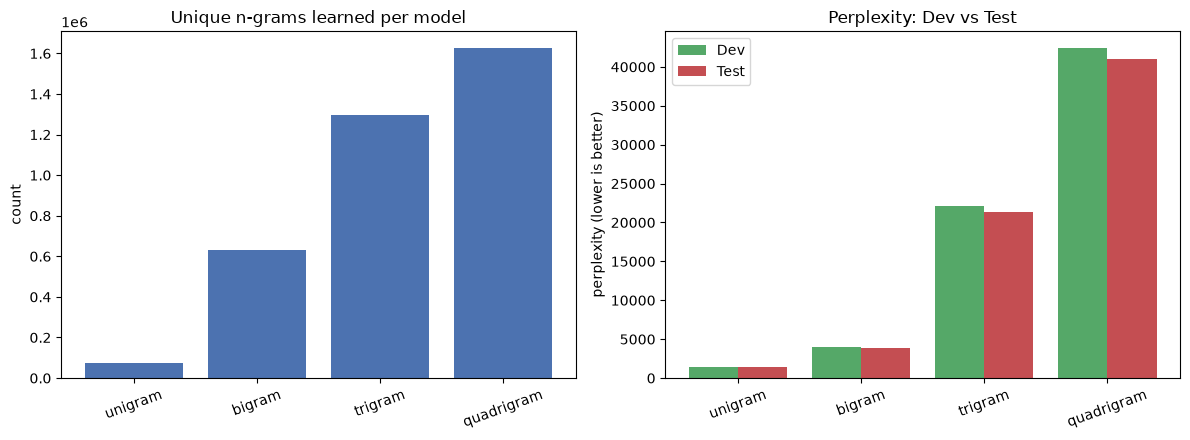

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["unigram", "bigram", "trigram", "quadrigram"]
plot_df = final_comparison_df.set_index("model").loc[order]

axes[0].bar(order, plot_df["unique_ngrams"], color="#4C72B0")
axes[0].set_title("Unique n-grams learned per model")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

x = range(len(order))
axes[1].bar([i - 0.2 for i in x], plot_df["dev_perplexity_aggregate"], width=0.4, label="Dev", color="#55A868")
axes[1].bar([i + 0.2 for i in x], plot_df["test_perplexity_aggregate"], width=0.4, label="Test", color="#C44E52")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(order, rotation=20)
axes[1].set_title("Perplexity: Dev vs Test")
axes[1].set_ylabel("perplexity (lower is better)")
axes[1].legend()

plt.tight_layout()
plt.show()

# NOTE: the chart is shown above and is embedded in this notebook's saved output
# (visible whenever you open the .ipynb) — it is intentionally NOT written into the
# results JSON, since a chart is an image, not human-readable text.


**Reading the comparison:** more context (higher `n`) means vastly more unique n-grams to
learn from the same data, so contexts get sparser. That's why perplexity typically
**improves** from unigram → bigram, then often **rises again** for trigram/quadrigram —
Laplace's `+1`/`+V` correction over-penalizes the huge number of unseen higher-order n-grams.


## 9. (Optional) Generate text from each model

In [19]:
def generate_sentence(model, V, vocab_list, max_len=10):
    n = model["n"]
    context = ["<s>"] * (n - 1)
    output = []
    for _ in range(max_len):
        candidates = random.sample(vocab_list, min(500, len(vocab_list)))
        best_word, best_p = None, -1
        for w in candidates:
            ngram = tuple(context[-(n - 1):]) + (w,) if n > 1 else (w,)
            p = laplace_probability(ngram, model, V)
            if p > best_p:
                best_p, best_word = p, w
        if best_word == "</s>":
            break
        output.append(best_word)
        context.append(best_word)
    return output


vocab_list = list(vocab)
generated_samples = {}
for name, model in models.items():
    gen = generate_sentence(model, V, vocab_list)
    generated_samples[name] = " ".join(gen)
    print(f"{name:12s}: {generated_samples[name]}")

results["generated_samples"] = generated_samples


unigram     : अब लिया होगा रही आपके स्थिति भी इसके थी वहीं
bigram      : भाजपा राज्य निश्चित 1.40 ज्वेलर्स होमपेज चढ़े आरीफ साण्डी भेस
trigram     : वहीं लोकसभा स्पीकर सीसीएल कालान्तर NATIONAL एकबारगी कैलिफोर्नियां मश्विरा मेंहदराव
quadrigram  : मौके समर्थकों किरार जय बीओआरएल ईमानदारी कमेनियस खासी अखीलेश बारा


## 10. Save — ONE consolidated, human-readable results file

Everything computed above (corpus stats, split sizes, vocabulary, all 4 models' n-gram
counts, top n-grams, perplexity summary + full per-sentence arrays, final comparison
table, generated samples) is written to a single **JSON** file — plain text, openable in
any editor. N-gram tuples are turned into space-joined strings (e.g. `"<s> यह एक"`) as
JSON keys since JSON doesn't support tuple keys.


In [20]:
def ngram_dict_to_json_safe(d):
    """Convert {('w1','w2'): count} -> {'w1 w2': count} so it's valid, readable JSON."""
    return {" ".join(k): v for k, v in d.items()}


json_results = {
    "corpus_stats": results["corpus_stats"],
    "split_sizes": results["split_sizes"],
    "vocab_size": results["vocab_size"],
    "vocabulary": sorted(results["vocab"]),
    "model_summary": results["model_summary"].to_dict(orient="records"),
    "top_ngrams": results["top_ngrams"],
    "models": {
        name: {
            "n": m["n"],
            "ngram_counts": ngram_dict_to_json_safe(m["ngram_counts"]),
            "context_counts": ngram_dict_to_json_safe(m["context_counts"]),
        }
        for name, m in results["models"].items()
    },
    "perplexity_summary": results["perplexity_summary"].to_dict(orient="records"),
    "per_sentence_perplexities": results["per_sentence_perplexities"],
    "final_comparison": results["final_comparison"].to_dict(orient="records"),
    "generated_samples": results["generated_samples"],
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)

print(f"Saved consolidated results -> {os.path.abspath(RESULTS_PATH)}  "
      f"({os.path.getsize(RESULTS_PATH)/1e6:.2f} MB, plain text JSON — open it directly to inspect)")
print(f"Tokenized corpus cache     -> {os.path.abspath(TOKENIZED_PATH)}  "
      f"({os.path.getsize(TOKENIZED_PATH)/1e6:.2f} MB, plain text CSV)")
print("\nThat is the only two files written to disk, both plain text. To reload the results later:")
print("  with open(\"results/assignment4_results.json\", \"r\", encoding=\"utf-8\") as f:")
print("      results = json.load(f)")


Saved consolidated results -> /Users/ritweekraj/Desktop/NLP/Assignment_4/results/assignment4_results.json  (295.27 MB, plain text JSON — open it directly to inspect)
Tokenized corpus cache     -> /Users/ritweekraj/Desktop/NLP/Assignment_4/data/hindi_tokenized_corpus.csv  (23.39 MB, plain text CSV)

That is the only two files written to disk, both plain text. To reload the results later:
  with open("results/assignment4_results.json", "r", encoding="utf-8") as f:
      results = json.load(f)


---
### Notes for your README.md

- **Data**: `ai4bharat/IndicCorpV2`, split `hin_Deva`, ≥ 1,000,000 tokenized sentences (cached in `data/hindi_tokenized_corpus.csv`, plain text), split into train / dev (1000) / test (1000).
- **Models**: unigram, bigram, trigram, quadrigram with `<s>`/`</s>` padding.
- **Smoothing**: Add-one (Laplace): $P(w_n\mid w_1,\dots,w_{n-1}) = \dfrac{C(w_1,\dots,w_n)+1}{C(w_1,\dots,w_{n-1})+V}$.
- **Evaluation**: aggregate + per-sentence perplexity on dev/test for all 4 models.
- **All results** (stats, counts, top n-grams, perplexities, comparison table, generated text) live in one plain-text file: `results/assignment4_results.json`. The comparison chart is embedded directly in this notebook's saved output.
